In [16]:
%load_ext autoreload
%autoreload 2

import os, sys

# Load imports from the src directory
sys.path.insert(0, "..")

from spec.enums import MainTableColumns as Cols
import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
from datasets import cs1eng

# Select a dataset by setting the config variable
config = cs1eng.S24


dataset_name, dataset_semester = config.name.split('_')
dataset_root_dir = os.path.join('..', '..', 'sample_data', dataset_name, dataset_semester)
dataset = config.load(dataset_root_dir)

In [ ]:
# Just get the first few thousand rows for testing and quicker loading
sample_size = 10000
main_table_sample = dataset.get_main_table_head(sample_size)
# main_table_sample

In [27]:
most_common_problem = main_table_sample[Cols.ProblemID].value_counts().idxmax()
most_common_problem

'week2debug'

In [28]:
problem_subset = main_table_sample[main_table_sample[Cols.ProblemID] == most_common_problem]
problem_subset[Cols.SubjectID].nunique()

17

In [38]:
problem_codestates = dataset.get_codestates(problem_subset[Cols.CodeStateID].unique())
problem_codestates.head()

,CodeStateID,Code
0,898,"""""""\r\n Author: [*************]\r\n Emai..."
1,899,"""""""\r\n Author: [**************]\r\n Ema..."
2,900,"""""""\r\n Author: [***************]\r\n Em..."
3,901,"""""""\r\n Author: [****************]\r\n E..."
4,902,"""""""\r\n Author: [*****************]\r\n ..."


In [41]:
logs_with_code = pd.merge(
    problem_subset,
    problem_codestates,
    on=Cols.CodeStateID,
)

In [42]:
from analytics.code.python.clean import CleanPythonPreprocessor
from spec.enums import CodeStatesTableColumns as CodeCols

cleaner = CleanPythonPreprocessor()

cleaned_codestates = cleaner.fit_transform(logs_with_code[CodeCols.Code])
for i in range(2):
    print(f"Original:\n{logs_with_code.iloc[i][CodeCols.Code]}")
    print(f"Cleaned:\n{cleaned_codestates[i]}")
    print()

Original:
"""
   Author:  [*************]
    Email:  [***********]
    Class:  CSC 111 Spring 2024
      Lab:  [Lab Section Number]

  Program:  [Assignment # and Name]
  Purpose:  [A one-paragraph description of this program]

  Bugs: [A list of remaining problems or None]

#== ACKNOWLEDGEMENTS =========================================================
Note any and all help you received on this program module, including class
notes, Piazza, etc.
#=============================================================================

"""

#asks the user for input on these questions
slip_num = (input("How many times did you slip when walking into a building while it was raining? ")
num_students = (input("How many students do you think go to NC State? ")
percent_slip = int(input("What percentage of people do you think are clumsy enough to slip in the rain?(enter whole number) "))

#calculates the percent as a decimal
dec_percent_slip = percent_slip // 100

#calculates the total slips
people_slips

In [43]:
from sklearn.feature_extraction.text import CountVectorizer
token_pattern = r"[\w]+|[^\s]|[ ]{4}"
ngram_range = (1,3)
vectorizer = CountVectorizer(
    lowercase=False,
    token_pattern=token_pattern,
    ngram_range=ngram_range
)

X = vectorizer.fit_transform(cleaned_codestates)
X.shape

(5213, 1247)

In [44]:
# Convert to 2D using TSNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X.toarray())
X_tsne

array([[-14.504756 , -12.267775 ],
       [-14.547367 , -12.250641 ],
       [-14.481187 , -12.277919 ],
       ...,
       [ 23.028326 , -19.989664 ],
       [ 12.810884 ,  13.4135475],
       [ 12.810884 ,  13.4135475]], shape=(5213, 2), dtype=float32)

<Axes: >

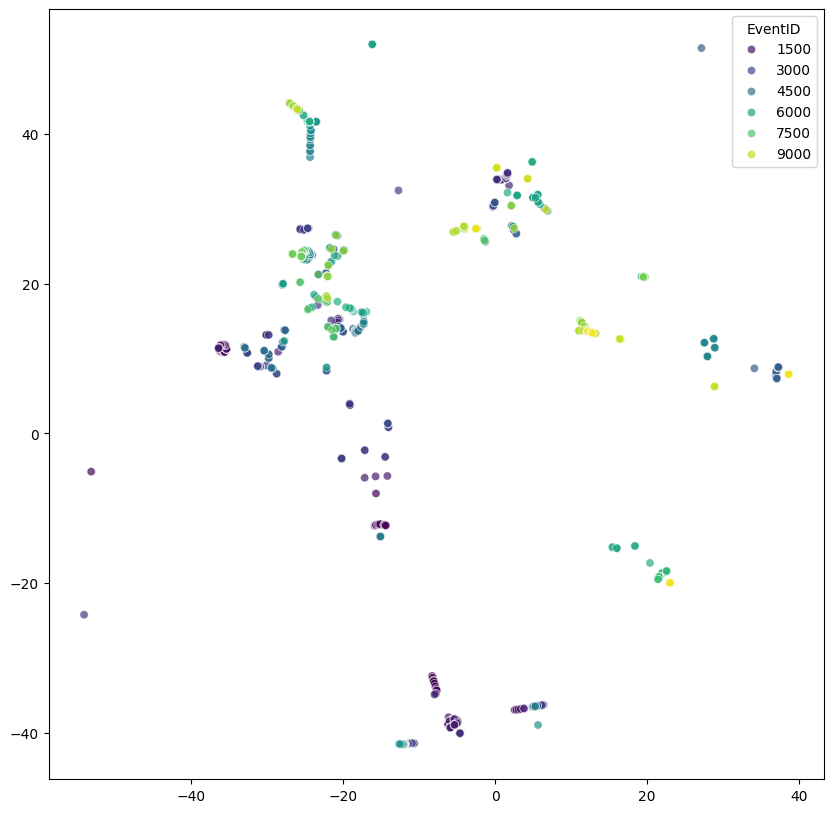

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=logs_with_code[Cols.EventID], palette='viridis', alpha=0.7)